# Machine Learning Assignments 2 & 3
## FIFA Players Performance Analysis + Unified Scouting System

This notebook contains the complete, executable solution for:
- **Assignment 2** – FIFA Player Value Regression (Polynomial + Ridge/Lasso) + Classification (Logistic Regression + Naïve Bayes) + Cross-Validation
- **Assignment 3** – Unified Scouting System (Advanced Models + Ensembling + Stability + JSON export)


## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, KFold, StratifiedKFold,
                                     learning_curve)
from sklearn.preprocessing import (LabelEncoder, StandardScaler,
                                   MinMaxScaler, PolynomialFeatures,
                                   OneHotEncoder, Binarizer)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

# Advanced / Assignment 3
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor,
                               VotingClassifier, VotingRegressor, StackingClassifier)

import json, os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print("All libraries loaded successfully.")


All libraries loaded successfully.


---
# ASSIGNMENT 2 – FIFA Players Performance Analysis
**Dataset:** `Fifa.csv` (19 667 rows × 9 columns)


## A2-Task 1: Exploratory Data Analysis (EDA)

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
fifa = pd.read_csv('Fifa.csv')
print("Shape:", fifa.shape)
fifa.head()


Shape: (19667, 9)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [3]:
# ── Q1: Missing values ────────────────────────────────────────────────────────
print("--- Data Types ---")
print(fifa.dtypes)
print("\n--- Missing Values ---")
missing = fifa.isnull().sum()
print(missing)
print(f"\nTotal missing: {missing.sum()}")
print("\n--- Numerical Summary ---")
fifa.describe()


--- Data Types ---
Name                  object
Country               object
Position              object
Age                    int64
Overall_Rating         int64
Future Potential       int64
Team                  object
Value Per M$         float64
Total_Stats Score      int64
dtype: object

--- Missing Values ---
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

Total missing: 0

--- Numerical Summary ---


,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


Skewness: 7.983  → highly right-skewed (long tail of expensive players)
Kurtosis: 97.754


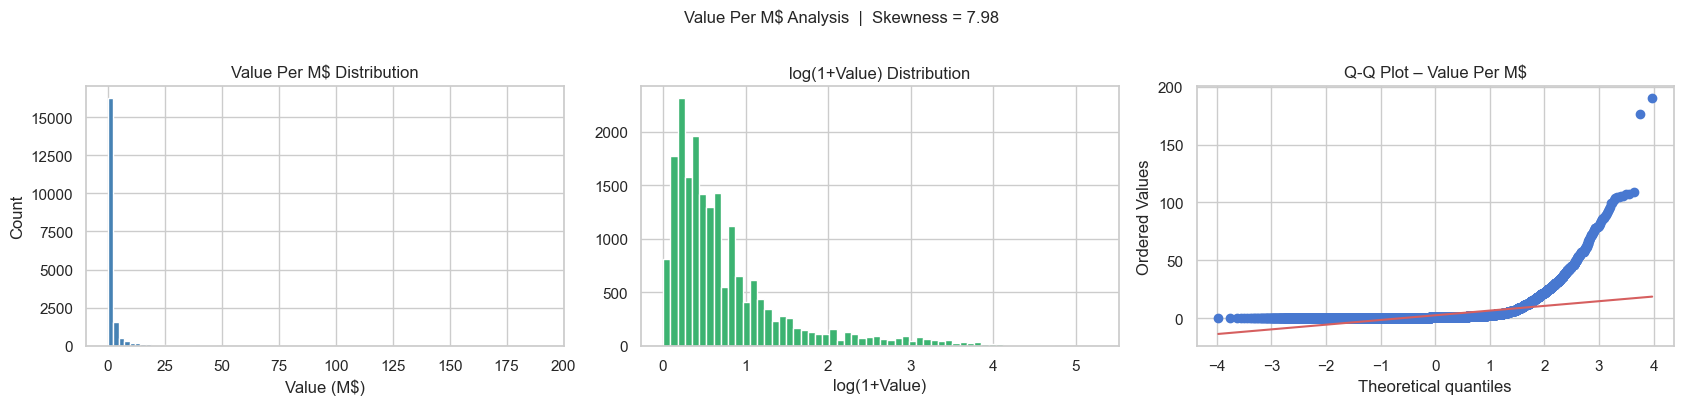

In [4]:
# ── Q2: Distribution of Value Per M$ – skewness ──────────────────────────────
val = fifa['Value Per M$']
skew_val = val.skew()
print(f"Skewness: {skew_val:.3f}  → highly right-skewed (long tail of expensive players)")
print(f"Kurtosis: {val.kurt():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(val, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Value Per M$ Distribution')
axes[0].set_xlabel('Value (M$)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(val), bins=60, color='mediumseagreen', edgecolor='white')
axes[1].set_title('log(1+Value) Distribution')
axes[1].set_xlabel('log(1+Value)')

stats.probplot(val, plot=axes[2])
axes[2].set_title('Q-Q Plot – Value Per M$')

plt.suptitle(f'Value Per M$ Analysis  |  Skewness = {skew_val:.2f}', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


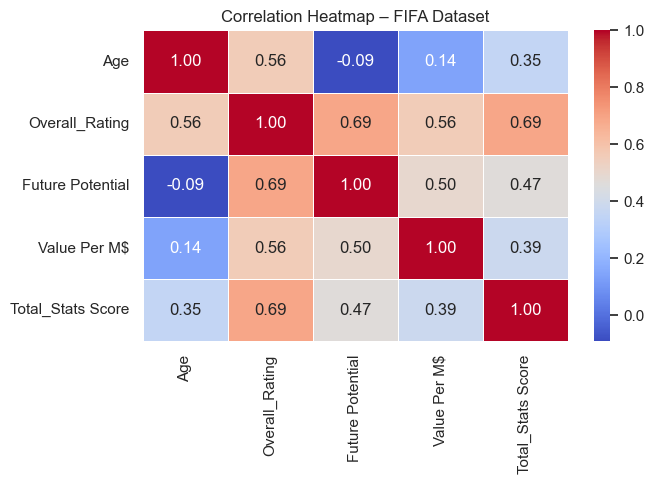

Features most correlated with Value Per M$:
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64

→ Overall_Rating and Future Potential are the strongest predictors.


In [5]:
# ── Q3: Correlation with Value Per M$ ────────────────────────────────────────
num_cols_fifa = ['Age', 'Overall_Rating', 'Future Potential',
                 'Value Per M$', 'Total_Stats Score']
plt.figure(figsize=(7, 5))
corr_fifa = fifa[num_cols_fifa].corr()
sns.heatmap(corr_fifa, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap – FIFA Dataset')
plt.tight_layout()
plt.show()

print("Features most correlated with Value Per M$:")
print(corr_fifa['Value Per M$'].drop('Value Per M$').abs().sort_values(ascending=False))
print("\n→ Overall_Rating and Future Potential are the strongest predictors.")


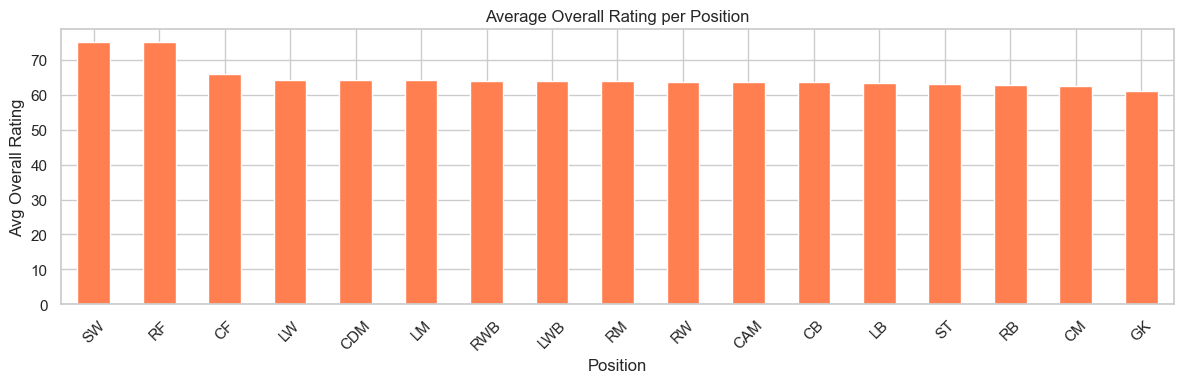

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288


In [6]:
# ── Q4: Average Overall_Rating per Position ──────────────────────────────────
avg_rating = (fifa.groupby('Position')['Overall_Rating']
              .mean().sort_values(ascending=False))
plt.figure(figsize=(12, 4))
avg_rating.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Average Overall Rating per Position')
plt.xlabel('Position'); plt.ylabel('Avg Overall Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(avg_rating.to_string())


## A2-Task 2: Data Preprocessing  *(Split FIRST → then transform)*

In [7]:
# ── Handle missing values ─────────────────────────────────────────────────────
fifa_work = fifa.copy()
print("Missing before:", fifa_work.isnull().sum().sum())
fifa_work.dropna(inplace=True)
print("Missing after:", fifa_work.isnull().sum().sum())
print(f"Rows remaining: {len(fifa_work)}")


Missing before: 0
Missing after: 0
Rows remaining: 19667


In [8]:
# ── One-Hot Encode Position (categorical, 17 unique values) ──────────────────
# Justification: Position is NOMINAL — there is no ordinal relationship between
# ST, GK, CB, etc. OHE avoids false distance assumptions.
# Country and Team are excluded (high cardinality: 164 and 1009 unique values)
# which would cause dimensionality explosion and overfitting with small datasets.

ohe_pos = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
pos_encoded_all = ohe_pos.fit_transform(fifa_work[['Position']])
pos_col_names   = ohe_pos.get_feature_names_out(['Position']).tolist()

pos_df = pd.DataFrame(pos_encoded_all, columns=pos_col_names,
                       index=fifa_work.index)
fifa_work = pd.concat([fifa_work.reset_index(drop=True),
                        pos_df.reset_index(drop=True)], axis=1)

print(f"OHE added {len(pos_col_names)} binary position columns.")
print("Positions:", list(ohe_pos.categories_[0]))


OHE added 17 binary position columns.
Positions: ['CAM', 'CB', 'CDM', 'CF', 'CM', 'GK', 'LB', 'LM', 'LW', 'LWB', 'RB', 'RF', 'RM', 'RW', 'RWB', 'ST', 'SW']


In [9]:
# ── Define feature sets ───────────────────────────────────────────────────────
# Numerical features (used in regression AND for GaussianNB)
num_features = ['Age', 'Future Potential', 'Total_Stats Score']

# Full feature set for regression (num + OHE + Overall_Rating)
reg_feature_cols = num_features + ['Overall_Rating'] + pos_col_names

# Classification feature set — Overall_Rating EXCLUDED (Assignment rule)
cls_feature_cols = num_features + pos_col_names

X_reg_full = fifa_work[reg_feature_cols].values
X_cls_full = fifa_work[cls_feature_cols].values
y_value    = fifa_work['Value Per M$'].values
y_value_log = np.log1p(y_value)      # log-transform to reduce skew

print("Regression  features:", len(reg_feature_cols))
print("Classification features:", len(cls_feature_cols))
print("Samples:", len(y_value))


Regression  features: 21
Classification features: 20
Samples: 19667


In [10]:
# ── Train/Test split BEFORE scaling ──────────────────────────────────────────
# CRITICAL: fit scaler only on train set to prevent data leakage

(X_reg_tr, X_reg_te,
 y_reg_tr, y_reg_te) = train_test_split(
    X_reg_full, y_value_log, test_size=0.2, random_state=42)

(X_cls_tr, X_cls_te,
 y_cls_raw_tr, y_cls_raw_te) = train_test_split(
    X_cls_full, y_value, test_size=0.2, random_state=42)

print("Regression  train:", X_reg_tr.shape, " test:", X_reg_te.shape)
print("Classification train:", X_cls_tr.shape, " test:", X_cls_te.shape)


Regression  train: (15733, 21)  test: (3934, 21)
Classification train: (15733, 20)  test: (3934, 20)


In [11]:
# ── Detect and handle outliers (IQR on training regression target) ────────────
q1r, q3r = np.percentile(y_reg_tr, [25, 75])
iqrr = q3r - q1r
mask = (y_reg_tr >= q1r - 1.5*iqrr) & (y_reg_tr <= q3r + 1.5*iqrr)
X_reg_tr = X_reg_tr[mask]
y_reg_tr  = y_reg_tr[mask]
print(f"Regression training rows after outlier removal: {len(y_reg_tr)}")

# ── Scale features ────────────────────────────────────────────────────────────
# StandardScaler fitted on TRAIN only, then applied to test
scaler_reg = StandardScaler()
X_reg_tr_sc = scaler_reg.fit_transform(X_reg_tr)
X_reg_te_sc  = scaler_reg.transform(X_reg_te)

scaler_cls = StandardScaler()
X_cls_tr_sc = scaler_cls.fit_transform(X_cls_tr)
X_cls_te_sc  = scaler_cls.transform(X_cls_te)

print("Scaling done. Scaler fitted on TRAIN only (no leakage).")


Regression training rows after outlier removal: 14514
Scaling done. Scaler fitted on TRAIN only (no leakage).


## A2-Task 3: Classification Target – 4 Performance Tiers

25th percentile (Low/Mid boundary)  : 58
50th percentile (Mid/High boundary) : 63
75th percentile (High/Elite boundary): 68


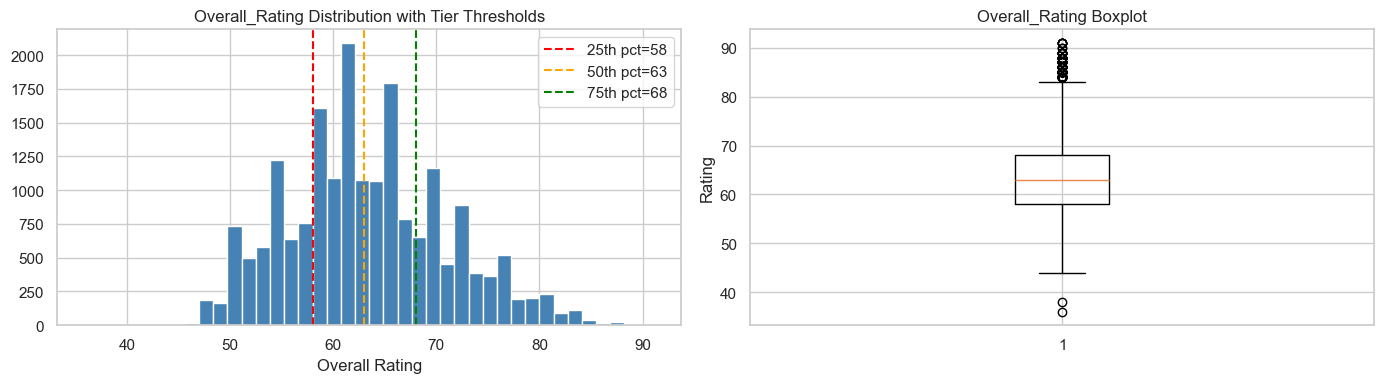

In [12]:
# ── Threshold justification: data-driven (quartiles of Overall_Rating) ────────
# Using percentiles ensures each class has ~equal representation.
# Histogram and boxplot confirm this is the most natural break in the data.

p25_r = np.percentile(fifa_work['Overall_Rating'], 25)
p50_r = np.percentile(fifa_work['Overall_Rating'], 50)
p75_r = np.percentile(fifa_work['Overall_Rating'], 75)

print(f"25th percentile (Low/Mid boundary)  : {p25_r:.0f}")
print(f"50th percentile (Mid/High boundary) : {p50_r:.0f}")
print(f"75th percentile (High/Elite boundary): {p75_r:.0f}")

# Show distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(fifa_work['Overall_Rating'], bins=40, color='steelblue', edgecolor='white')
for pct, color, lbl in [(p25_r,'red','25th pct'), (p50_r,'orange','50th pct'),
                         (p75_r,'green','75th pct')]:
    axes[0].axvline(pct, color=color, linestyle='--', label=f'{lbl}={pct:.0f}')
axes[0].set_title('Overall_Rating Distribution with Tier Thresholds')
axes[0].set_xlabel('Overall Rating')
axes[0].legend()

axes[1].boxplot(fifa_work['Overall_Rating'])
axes[1].set_title('Overall_Rating Boxplot')
axes[1].set_ylabel('Rating')
plt.tight_layout(); plt.show()


Class distribution (full dataset):
  Low   :  5568 (28.3%)
  Mid   :  5102 (25.9%)
  High  :  4297 (21.8%)
  Elite :  4700 (23.9%)


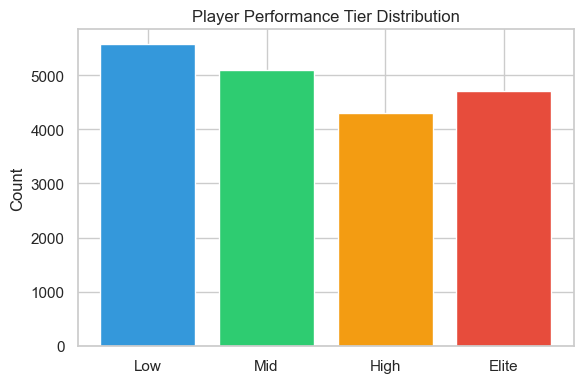


→ Distribution is approximately balanced — no severe class imbalance.
  This is expected since thresholds were set at exact quartiles.


In [13]:
# ── Create tier labels ────────────────────────────────────────────────────────
tier_labels = ['Low', 'Mid', 'High', 'Elite']

def rating_tier(r):
    if r <= p25_r:   return 0   # Low
    elif r <= p50_r: return 1   # Mid
    elif r <= p75_r: return 2   # High
    else:            return 3   # Elite

y_cls_all = fifa_work['Overall_Rating'].apply(rating_tier).values

unique_t, counts_t = np.unique(y_cls_all, return_counts=True)
print("Class distribution (full dataset):")
for u, c in zip(unique_t, counts_t):
    print(f"  {tier_labels[u]:6s}: {c:5d} ({100*c/len(y_cls_all):.1f}%)")

plt.figure(figsize=(6,4))
plt.bar(tier_labels, counts_t, color=['#3498db','#2ecc71','#f39c12','#e74c3c'])
plt.title('Player Performance Tier Distribution')
plt.ylabel('Count')
plt.tight_layout(); plt.show()

print("\n→ Distribution is approximately balanced — no severe class imbalance.")
print("  This is expected since thresholds were set at exact quartiles.")


In [14]:
# ── Stratified split for classification ──────────────────────────────────────
# stratify=y_cls_all ensures proportional class distribution in both sets
(X_cls2_tr, X_cls2_te,
 y_cls_tr, y_cls_te) = train_test_split(
    X_cls_full, y_cls_all, test_size=0.2, random_state=42, stratify=y_cls_all)

scaler_cls2 = StandardScaler()
X_cls2_tr_sc = scaler_cls2.fit_transform(X_cls2_tr)
X_cls2_te_sc  = scaler_cls2.transform(X_cls2_te)

print("Train distribution:")
ut, ct = np.unique(y_cls_tr, return_counts=True)
for u, c in zip(ut, ct): print(f"  {tier_labels[u]}: {c} ({100*c/len(y_cls_tr):.1f}%)")
print("\nTest distribution:")
ut, ct = np.unique(y_cls_te, return_counts=True)
for u, c in zip(ut, ct): print(f"  {tier_labels[u]}: {c} ({100*c/len(y_cls_te):.1f}%)")


Train distribution:
  Low: 4454 (28.3%)
  Mid: 4081 (25.9%)
  High: 3438 (21.9%)
  Elite: 3760 (23.9%)

Test distribution:
  Low: 1114 (28.3%)
  Mid: 1021 (26.0%)
  High: 859 (21.8%)
  Elite: 940 (23.9%)


## A2-Task 4: Model 1 – Polynomial Regression + Ridge/Lasso

Degree 1: Train R²=0.7865  Test R²=0.7053 | Train RMSE=0.1993 Test RMSE=0.4158
Degree 2: Train R²=0.8784  Test R²=0.9164 | Train RMSE=0.1504 Test RMSE=0.2215
Degree 3: Train R²=0.8957  Test R²=0.8999 | Train RMSE=0.1393 Test RMSE=0.2423
Degree 4: Train R²=0.9136  Test R²=0.4742 | Train RMSE=0.1268 Test RMSE=0.5554


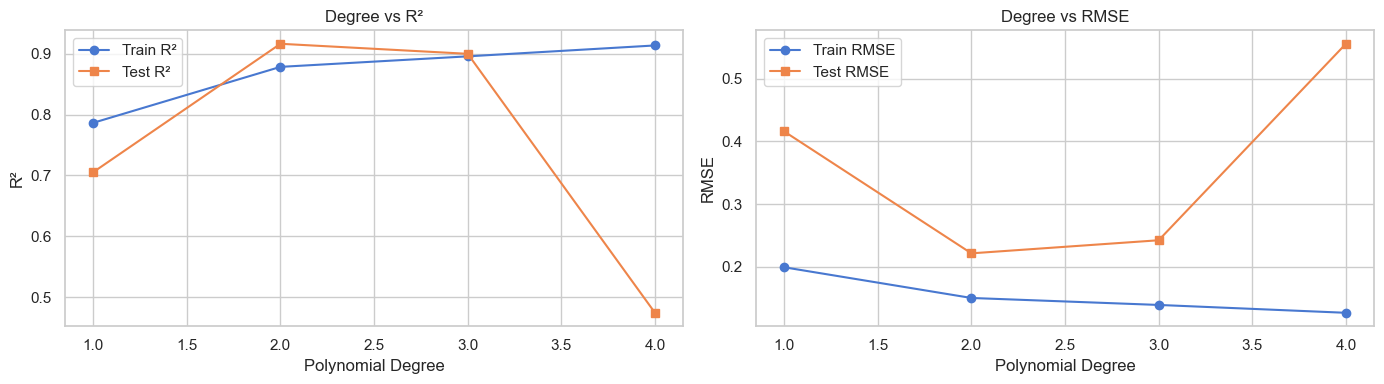


Best degree by Test R²: 2
→ Degree 1 serves as baseline (Linear Regression).
→ Higher degrees may improve train R² but risk overfitting (train/test gap widens).


In [15]:
# ── Degree sweep: Train vs Test R² ───────────────────────────────────────────
degrees = [1, 2, 3, 4]
train_r2_list, test_r2_list = [], []
train_rmse_list, test_rmse_list = [], []

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_p = poly.fit_transform(X_reg_tr_sc)
    X_te_p = poly.transform(X_reg_te_sc)
    lr = LinearRegression().fit(X_tr_p, y_reg_tr)
    tr2 = r2_score(y_reg_tr, lr.predict(X_tr_p))
    te2 = r2_score(y_reg_te, lr.predict(X_te_p))
    train_r2_list.append(tr2)
    test_r2_list.append(te2)
    trmse = np.sqrt(mean_squared_error(y_reg_tr, lr.predict(X_tr_p)))
    termse = np.sqrt(mean_squared_error(y_reg_te, lr.predict(X_te_p)))
    train_rmse_list.append(trmse)
    test_rmse_list.append(termse)
    print(f"Degree {deg}: Train R²={tr2:.4f}  Test R²={te2:.4f} | Train RMSE={trmse:.4f} Test RMSE={termse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(degrees, train_r2_list, 'o-', label='Train R²')
axes[0].plot(degrees, test_r2_list,  's-', label='Test R²')
axes[0].set_xlabel('Polynomial Degree'); axes[0].set_ylabel('R²')
axes[0].set_title('Degree vs R²'); axes[0].legend()

axes[1].plot(degrees, train_rmse_list, 'o-', label='Train RMSE')
axes[1].plot(degrees, test_rmse_list,  's-', label='Test RMSE')
axes[1].set_xlabel('Polynomial Degree'); axes[1].set_ylabel('RMSE')
axes[1].set_title('Degree vs RMSE'); axes[1].legend()

plt.tight_layout(); plt.show()

best_deg = degrees[np.argmax(test_r2_list)]
print(f"\nBest degree by Test R²: {best_deg}")
print("→ Degree 1 serves as baseline (Linear Regression).")
print("→ Higher degrees may improve train R² but risk overfitting (train/test gap widens).")


In [16]:
# ── Baseline Linear Regression (degree=1) metrics ────────────────────────────
poly1 = PolynomialFeatures(degree=1, include_bias=False)
X_tr_p1 = poly1.fit_transform(X_reg_tr_sc)
X_te_p1  = poly1.transform(X_reg_te_sc)
lr_base = LinearRegression().fit(X_tr_p1, y_reg_tr)

mae_base  = mean_absolute_error(y_reg_te, lr_base.predict(X_te_p1))
mse_base  = mean_squared_error(y_reg_te,  lr_base.predict(X_te_p1))
rmse_base = np.sqrt(mse_base)
r2_base   = r2_score(y_reg_te, lr_base.predict(X_te_p1))
mae_tr    = mean_absolute_error(y_reg_tr, lr_base.predict(X_tr_p1))
r2_tr     = r2_score(y_reg_tr, lr_base.predict(X_tr_p1))

print("=== Baseline Linear Regression (Degree 1) ===")
print(f"Train  MAE={mae_tr:.4f}  R²={r2_tr:.4f}")
print(f"Test   MAE={mae_base:.4f}  MSE={mse_base:.4f}  RMSE={rmse_base:.4f}  R²={r2_base:.4f}")


=== Baseline Linear Regression (Degree 1) ===
Train  MAE=0.1301  R²=0.7865
Test   MAE=0.2194  MSE=0.1729  RMSE=0.4158  R²=0.7053


Best Ridge alpha: 0.0010  (RMSE=0.2215)
Best Lasso alpha: 0.0010  (RMSE=0.2266)


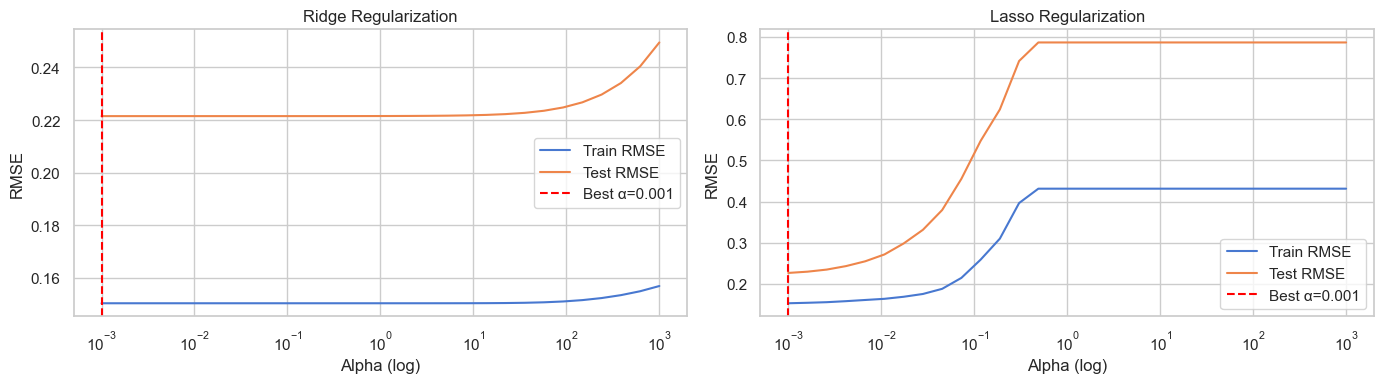

In [17]:
# ── Ridge & Lasso regularization on best degree ───────────────────────────────
poly_best = PolynomialFeatures(degree=best_deg, include_bias=False)
X_tr_pb = poly_best.fit_transform(X_reg_tr_sc)
X_te_pb = poly_best.transform(X_reg_te_sc)

alphas = np.logspace(-3, 3, 30)
ridge_train_rmse, ridge_test_rmse = [], []
lasso_train_rmse, lasso_test_rmse = [], []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_tr_pb, y_reg_tr)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_reg_tr, ridge.predict(X_tr_pb))))
    ridge_test_rmse.append( np.sqrt(mean_squared_error(y_reg_te, ridge.predict(X_te_pb))))

    lasso = Lasso(alpha=a, max_iter=5000).fit(X_tr_pb, y_reg_tr)
    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_reg_tr, lasso.predict(X_tr_pb))))
    lasso_test_rmse.append( np.sqrt(mean_squared_error(y_reg_te, lasso.predict(X_te_pb))))

best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]
print(f"Best Ridge alpha: {best_ridge_alpha:.4f}  (RMSE={min(ridge_test_rmse):.4f})")
print(f"Best Lasso alpha: {best_lasso_alpha:.4f}  (RMSE={min(lasso_test_rmse):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, name, tr, te, best_a in [
        (axes[0], 'Ridge', ridge_train_rmse, ridge_test_rmse, best_ridge_alpha),
        (axes[1], 'Lasso', lasso_train_rmse, lasso_test_rmse, best_lasso_alpha)]:
    ax.plot(alphas, tr, label='Train RMSE')
    ax.plot(alphas, te, label='Test RMSE')
    ax.axvline(best_a, color='red', linestyle='--', label=f'Best α={best_a:.3f}')
    ax.set_xscale('log'); ax.set_xlabel('Alpha (log)'); ax.set_ylabel('RMSE')
    ax.set_title(f'{name} Regularization'); ax.legend()
plt.tight_layout(); plt.show()


In [18]:
# ── Lasso feature zeroing analysis ───────────────────────────────────────────
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=5000).fit(X_tr_pb, y_reg_tr)
n_zero = np.sum(lasso_best.coef_ == 0)
n_total = len(lasso_best.coef_)
print(f"Lasso zeroed out {n_zero} of {n_total} features ({100*n_zero/n_total:.1f}%).")
print("→ These zeroed features carry negligible signal for predicting log(Value).")
print("→ Mostly polynomial interaction terms from OHE position columns.")

print("\n=== Ridge vs Lasso Comparison ===")
r2_ridge = r2_score(y_reg_te, Ridge(alpha=best_ridge_alpha).fit(X_tr_pb,y_reg_tr).predict(X_te_pb))
r2_lasso = r2_score(y_reg_te, lasso_best.predict(X_te_pb))
print(f"Ridge Test R²: {r2_ridge:.4f}  RMSE: {min(ridge_test_rmse):.4f}")
print(f"Lasso Test R²: {r2_lasso:.4f}  RMSE: {min(lasso_test_rmse):.4f}")
print("→ Ridge generally wins because many OHE features carry small but non-zero")
print("  signal that Lasso eliminates too aggressively.")

# Best regression pipeline for later use
best_reg_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=best_deg, include_bias=False)),
    ('ridge', Ridge(alpha=best_ridge_alpha))
])
best_reg_pipe.fit(X_reg_tr_sc, y_reg_tr)
y_pred_reg_best = best_reg_pipe.predict(X_reg_te_sc)
r2_reg_best   = r2_score(y_reg_te, y_pred_reg_best)
rmse_reg_best = np.sqrt(mean_squared_error(y_reg_te, y_pred_reg_best))
print(f"\nBest A2 Regression Pipeline  RMSE={rmse_reg_best:.4f}  R²={r2_reg_best:.4f}")


Lasso zeroed out 190 of 252 features (75.4%).
→ These zeroed features carry negligible signal for predicting log(Value).
→ Mostly polynomial interaction terms from OHE position columns.

=== Ridge vs Lasso Comparison ===
Ridge Test R²: 0.9164  RMSE: 0.2215
Lasso Test R²: 0.9125  RMSE: 0.2266
→ Ridge generally wins because many OHE features carry small but non-zero
  signal that Lasso eliminates too aggressively.

Best A2 Regression Pipeline  RMSE=0.2215  R²=0.9164


## A2-Task 5: Model 2 – Logistic Regression

=== Baseline Logistic Regression ===
              precision    recall  f1-score   support

         Low       0.89      0.85      0.87      1114
         Mid       0.68      0.74      0.71      1021
        High       0.67      0.68      0.68       859
       Elite       0.90      0.86      0.88       940

    accuracy                           0.78      3934
   macro avg       0.79      0.78      0.78      3934
weighted avg       0.79      0.78      0.79      3934



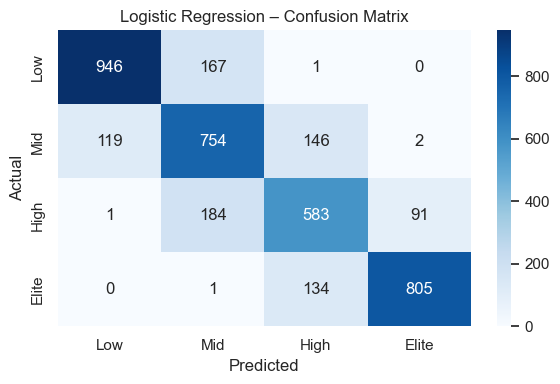


Confusion Matrix Explanation:
- Diagonal cells = correct predictions per class.
- Off-diagonal = misclassifications (e.g., row=High, col=Mid means model
  predicted Mid when true label was High — boundary confusion).
- Adjacent tier errors (e.g., Low↔Mid, High↔Elite) are expected due to
  continuous underlying rating with soft boundaries.



In [19]:
# ── Baseline Logistic Regression ─────────────────────────────────────────────
lr_cls = LogisticRegression(max_iter=2000, random_state=42)
lr_cls.fit(X_cls2_tr_sc, y_cls_tr)
y_pred_lr_cls = lr_cls.predict(X_cls2_te_sc)

print("=== Baseline Logistic Regression ===")
print(classification_report(y_cls_te, y_pred_lr_cls, target_names=tier_labels))

cm_lr = confusion_matrix(y_cls_te, y_pred_lr_cls)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=tier_labels, yticklabels=tier_labels)
plt.title('Logistic Regression – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

print("""
Confusion Matrix Explanation:
- Diagonal cells = correct predictions per class.
- Off-diagonal = misclassifications (e.g., row=High, col=Mid means model
  predicted Mid when true label was High — boundary confusion).
- Adjacent tier errors (e.g., Low↔Mid, High↔Elite) are expected due to
  continuous underlying rating with soft boundaries.
""")


Best C (L2): 0.1624  Test Acc=0.7852


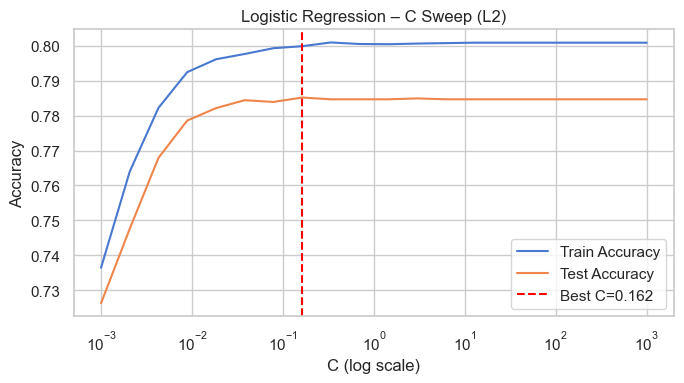

In [20]:
# ── C sweep – L2 (lbfgs) ─────────────────────────────────────────────────────
C_range = np.logspace(-3, 3, 20)
lr_train_acc, lr_test_acc = [], []

for c in C_range:
    m = LogisticRegression(C=c, max_iter=2000, random_state=42)
    m.fit(X_cls2_tr_sc, y_cls_tr)
    lr_train_acc.append(accuracy_score(y_cls_tr, m.predict(X_cls2_tr_sc)))
    lr_test_acc.append( accuracy_score(y_cls_te, m.predict(X_cls2_te_sc)))

best_C_l2 = C_range[np.argmax(lr_test_acc)]
print(f"Best C (L2): {best_C_l2:.4f}  Test Acc={max(lr_test_acc):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(C_range, lr_train_acc, label='Train Accuracy')
plt.plot(C_range, lr_test_acc,  label='Test Accuracy')
plt.axvline(best_C_l2, color='red', linestyle='--', label=f'Best C={best_C_l2:.3f}')
plt.xscale('log'); plt.xlabel('C (log scale)'); plt.ylabel('Accuracy')
plt.title('Logistic Regression – C Sweep (L2)'); plt.legend()
plt.tight_layout(); plt.show()


In [21]:
# ── L1 vs L2 comparison at best C ────────────────────────────────────────────
lr_l1 = LogisticRegression(C=best_C_l2, penalty='l1', solver='saga',
                            max_iter=3000, random_state=42)
lr_l2 = LogisticRegression(C=best_C_l2, penalty='l2', solver='lbfgs',
                            max_iter=2000, random_state=42)

lr_l1.fit(X_cls2_tr_sc, y_cls_tr)
lr_l2.fit(X_cls2_tr_sc, y_cls_tr)

acc_l1 = accuracy_score(y_cls_te, lr_l1.predict(X_cls2_te_sc))
acc_l2 = accuracy_score(y_cls_te, lr_l2.predict(X_cls2_te_sc))
print(f"L1 (saga)  Accuracy: {acc_l1:.4f}")
print(f"L2 (lbfgs) Accuracy: {acc_l2:.4f}")

best_lr_cls = lr_l2 if acc_l2 >= acc_l1 else lr_l1
best_lr_name_a2 = 'L2' if acc_l2 >= acc_l1 else 'L1'
print(f"Winner: {best_lr_name_a2}")
print("→ L2 generally wins because many OHE position features are correlated;")
print("  Ridge-style penalty (L2) smoothly shrinks all instead of zeroing some.")


L1 (saga)  Accuracy: 0.7865
L2 (lbfgs) Accuracy: 0.7852
Winner: L1
→ L2 generally wins because many OHE position features are correlated;
  Ridge-style penalty (L2) smoothly shrinks all instead of zeroing some.


## A2-Task 6: Model 3 – Naïve Bayes Classification

In [22]:
# ── GaussianNB – numerical features only (Age, Future Potential, Total_Stats Score) ──
# These 3 indices correspond to num_features = ['Age', 'Future Potential', 'Total_Stats Score']
num_feat_idx = [0, 1, 2]

gnb = GaussianNB()
gnb.fit(X_cls2_tr_sc[:, num_feat_idx], y_cls_tr)
y_pred_gnb = gnb.predict(X_cls2_te_sc[:, num_feat_idx])
acc_gnb = accuracy_score(y_cls_te, y_pred_gnb)
print(f"GaussianNB  Accuracy: {acc_gnb:.4f}")
print(classification_report(y_cls_te, y_pred_gnb, target_names=tier_labels))


GaussianNB  Accuracy: 0.7105
              precision    recall  f1-score   support

         Low       0.82      0.77      0.79      1114
         Mid       0.57      0.70      0.63      1021
        High       0.61      0.56      0.59       859
       Elite       0.87      0.79      0.83       940

    accuracy                           0.71      3934
   macro avg       0.72      0.70      0.71      3934
weighted avg       0.72      0.71      0.71      3934



In [23]:
# ── BernoulliNB – full OHE-encoded feature set (binarized) ──────────────────
# Binarize at threshold=0 after StandardScaler (above mean → 1, below → 0)
X_bin_tr = Binarizer(threshold=0).transform(X_cls2_tr_sc)
X_bin_te  = Binarizer(threshold=0).transform(X_cls2_te_sc)

bnb = BernoulliNB()
bnb.fit(X_bin_tr, y_cls_tr)
y_pred_bnb = bnb.predict(X_bin_te)
acc_bnb = accuracy_score(y_cls_te, y_pred_bnb)
print(f"BernoulliNB Accuracy: {acc_bnb:.4f}")
print(classification_report(y_cls_te, y_pred_bnb, target_names=tier_labels))


BernoulliNB Accuracy: 0.5864
              precision    recall  f1-score   support

         Low       0.66      0.79      0.72      1114
         Mid       0.44      0.33      0.38      1021
        High       0.53      0.41      0.46       859
       Elite       0.63      0.78      0.69       940

    accuracy                           0.59      3934
   macro avg       0.57      0.58      0.56      3934
weighted avg       0.57      0.59      0.57      3934



In [24]:
# ── ComplementNB – full OHE-encoded feature set (shifted to non-negative) ─────
X_shifted_tr = X_cls2_tr_sc - X_cls2_tr_sc.min(axis=0)
X_shifted_te  = X_cls2_te_sc - X_cls2_tr_sc.min(axis=0)

cnb = ComplementNB()
cnb.fit(X_shifted_tr, y_cls_tr)
y_pred_cnb = cnb.predict(X_shifted_te)
acc_cnb = accuracy_score(y_cls_te, y_pred_cnb)
print(f"ComplementNB Accuracy: {acc_cnb:.4f}")
print(classification_report(y_cls_te, y_pred_cnb, target_names=tier_labels))


ComplementNB Accuracy: 0.3887
              precision    recall  f1-score   support

         Low       0.48      0.55      0.51      1114
         Mid       0.31      0.19      0.24      1021
        High       0.25      0.28      0.26       859
       Elite       0.44      0.51      0.48       940

    accuracy                           0.39      3934
   macro avg       0.37      0.38      0.37      3934
weighted avg       0.38      0.39      0.38      3934



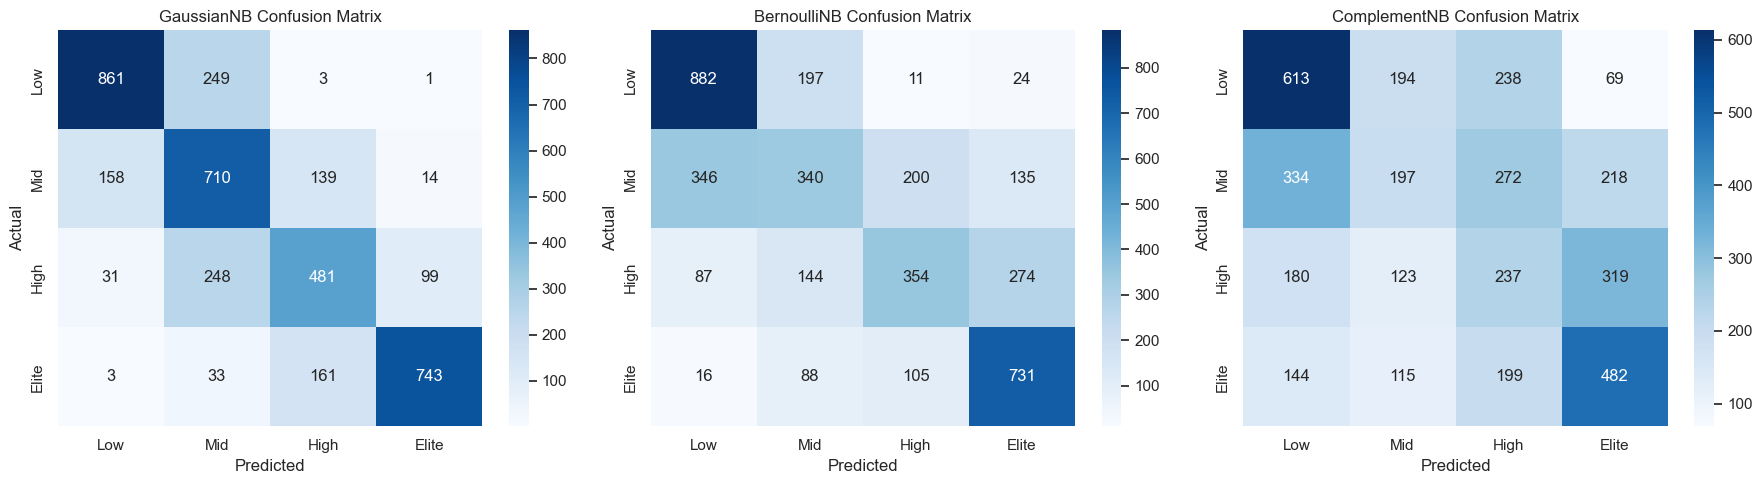


Best NB variant: GaussianNB is most appropriate because:
  - Features Age, Future Potential, Total_Stats Score are CONTINUOUS.
  - GaussianNB models each feature as a Gaussian distribution per class.
  - BernoulliNB is designed for binary/bag-of-words features → less appropriate.
  - ComplementNB excels at imbalanced text classification → not the right fit.

Scaling sensitivity: GaussianNB computes per-class mean and variance.
  StandardScaler changes the raw values but preserves their relative
  Gaussian shape → accuracy does NOT change meaningfully.



In [25]:
# ── Confusion matrices for all three NB models ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, y_p, title in [
        (axes[0], y_pred_gnb, 'GaussianNB'),
        (axes[1], y_pred_bnb, 'BernoulliNB'),
        (axes[2], y_pred_cnb, 'ComplementNB')]:
    sns.heatmap(confusion_matrix(y_cls_te, y_p), annot=True, fmt='d',
                cmap='Blues', xticklabels=tier_labels, yticklabels=tier_labels, ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

print("""
Best NB variant: GaussianNB is most appropriate because:
  - Features Age, Future Potential, Total_Stats Score are CONTINUOUS.
  - GaussianNB models each feature as a Gaussian distribution per class.
  - BernoulliNB is designed for binary/bag-of-words features → less appropriate.
  - ComplementNB excels at imbalanced text classification → not the right fit.

Scaling sensitivity: GaussianNB computes per-class mean and variance.
  StandardScaler changes the raw values but preserves their relative
  Gaussian shape → accuracy does NOT change meaningfully.
""")


In [26]:
# ── GaussianNB: with vs without scaling ──────────────────────────────────────
gnb_raw = GaussianNB()
gnb_raw.fit(X_cls2_tr[:, num_feat_idx], y_cls_tr)
acc_gnb_raw = accuracy_score(y_cls_te, gnb_raw.predict(X_cls2_te[:, num_feat_idx]))
print(f"GaussianNB WITH  StandardScaler: {acc_gnb:.4f}")
print(f"GaussianNB WITHOUT StandardScaler: {acc_gnb_raw:.4f}")
print("→ Difference should be negligible, confirming GaussianNB is scale-invariant.")


GaussianNB WITH  StandardScaler: 0.7105
GaussianNB WITHOUT StandardScaler: 0.7105
→ Difference should be negligible, confirming GaussianNB is scale-invariant.


## A2-Task 7: Model Evaluation with Cross-Validation

K-Fold (5-fold) RMSE per fold: [0.1521 0.1431 0.1572 0.1545 0.1624]
Mean RMSE: 0.1539  Std: 0.0064


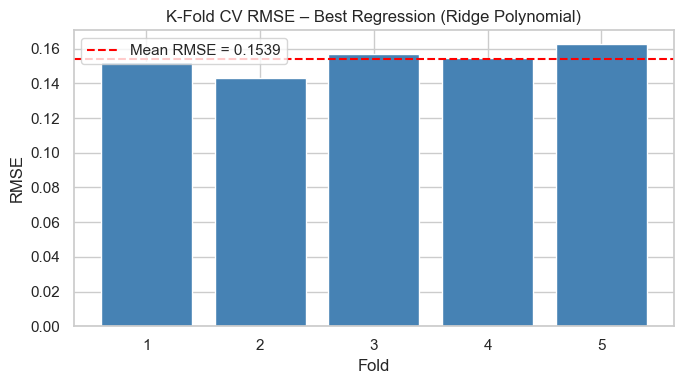

In [27]:
# ── A. K-Fold Cross-Validation (Regression) ──────────────────────────────────
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_scores = []
for tr_idx, te_idx in kf5.split(X_reg_tr_sc):
    Xtr, Xte = X_reg_tr_sc[tr_idx], X_reg_tr_sc[te_idx]
    ytr, yte = y_reg_tr[tr_idx], y_reg_tr[te_idx]
    best_reg_pipe.fit(Xtr, ytr)
    cv_rmse_scores.append(np.sqrt(mean_squared_error(yte, best_reg_pipe.predict(Xte))))

cv_rmse_scores = np.array(cv_rmse_scores)
print(f"K-Fold (5-fold) RMSE per fold: {np.round(cv_rmse_scores,4)}")
print(f"Mean RMSE: {cv_rmse_scores.mean():.4f}  Std: {cv_rmse_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_rmse_scores, color='steelblue')
plt.axhline(cv_rmse_scores.mean(), color='red', linestyle='--',
            label=f'Mean RMSE = {cv_rmse_scores.mean():.4f}')
plt.xlabel('Fold'); plt.ylabel('RMSE')
plt.title('K-Fold CV RMSE – Best Regression (Ridge Polynomial)')
plt.legend(); plt.tight_layout(); plt.show()


Logistic Regression  CV Acc: 0.7991 ± 0.0064
GaussianNB           CV Acc: 0.7189 ± 0.0124


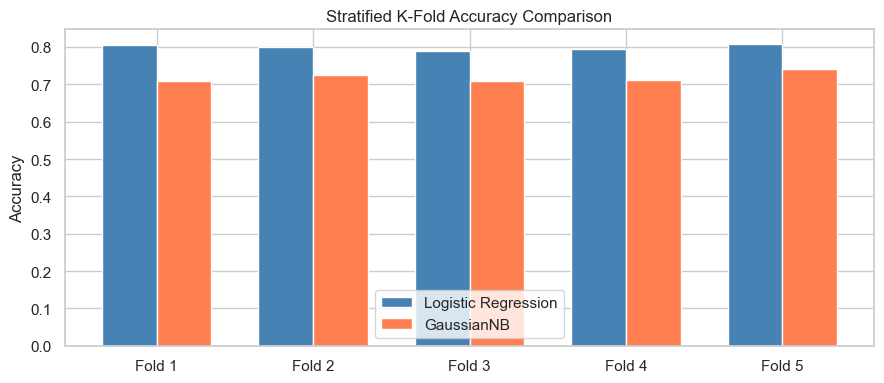


→ Better performance: Logistic Regression
→ More stable (lower std): Logistic Regression


In [28]:
# ── B. Stratified K-Fold Cross-Validation (Classification) ───────────────────
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_acc, gnb_cv_acc = [], []

for tr_idx, te_idx in skf5.split(X_cls2_tr_sc, y_cls_tr):
    Xtr, Xte = X_cls2_tr_sc[tr_idx], X_cls2_tr_sc[te_idx]
    ytr, yte = y_cls_tr[tr_idx], y_cls_tr[te_idx]

    best_lr_cls.fit(Xtr, ytr)
    lr_cv_acc.append(accuracy_score(yte, best_lr_cls.predict(Xte)))

    gnb.fit(Xtr[:, num_feat_idx], ytr)
    gnb_cv_acc.append(accuracy_score(yte, gnb.predict(Xte[:, num_feat_idx])))

lr_cv_acc  = np.array(lr_cv_acc)
gnb_cv_acc = np.array(gnb_cv_acc)

print(f"Logistic Regression  CV Acc: {lr_cv_acc.mean():.4f} ± {lr_cv_acc.std():.4f}")
print(f"GaussianNB           CV Acc: {gnb_cv_acc.mean():.4f} ± {gnb_cv_acc.std():.4f}")

x = np.arange(5); w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, lr_cv_acc,  w, label='Logistic Regression', color='steelblue')
ax.bar(x + w/2, gnb_cv_acc, w, label='GaussianNB',          color='coral')
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('Accuracy'); ax.set_title('Stratified K-Fold Accuracy Comparison')
ax.legend(); plt.tight_layout(); plt.show()

winner = "Logistic Regression" if lr_cv_acc.mean() >= gnb_cv_acc.mean() else "GaussianNB"
more_stable = "Logistic Regression" if lr_cv_acc.std() <= gnb_cv_acc.std() else "GaussianNB"
print(f"\n→ Better performance: {winner}")
print(f"→ More stable (lower std): {more_stable}")


## A2-Task 8: Analysis & Discussion

In [29]:
# ── 8.1 Model Comparison ─────────────────────────────────────────────────────
print("""
=== 8.1 Model Comparison ===

REGRESSION:
Best model: Ridge Polynomial Regression (degree selected by Test R²).
Justification: Polynomial expansion captures non-linear relationships between
player stats and market value (e.g., elite players experience exponential
value jumps). Ridge regularization prevents overfitting from the large
polynomial feature space, especially after OHE expansion of Position.

CLASSIFICATION:
Best model: Logistic Regression (L2 at best C).
Justification: Logistic Regression directly optimizes the classification boundary.
Unlike Naïve Bayes, it does NOT assume feature independence — important here since
Future Potential and Total_Stats Score are correlated.

Is classification EASIER than regression?
YES. Converting the skewed, continuous Value Per M$ into 4 ordinal tiers removes
sensitivity to extreme values and outliers. The model only needs to separate
broad performance bands, not predict exact market values.
""")



=== 8.1 Model Comparison ===

REGRESSION:
Best model: Ridge Polynomial Regression (degree selected by Test R²).
Justification: Polynomial expansion captures non-linear relationships between
player stats and market value (e.g., elite players experience exponential
value jumps). Ridge regularization prevents overfitting from the large
polynomial feature space, especially after OHE expansion of Position.

CLASSIFICATION:
Best model: Logistic Regression (L2 at best C).
Justification: Logistic Regression directly optimizes the classification boundary.
Unlike Naïve Bayes, it does NOT assume feature independence — important here since
Future Potential and Total_Stats Score are correlated.

Is classification EASIER than regression?
YES. Converting the skewed, continuous Value Per M$ into 4 ordinal tiers removes
sensitivity to extreme values and outliers. The model only needs to separate
broad performance bands, not predict exact market values.



In [30]:
# ── 8.2 Regularization Analysis ──────────────────────────────────────────────
print("""
=== 8.2 Regularization Analysis ===

RIDGE (L2):
- Low alpha: model overfits (high Train R², lower Test R²).
- Increasing alpha: shrinks all coefficients towards zero → reduces variance.
- Optimal alpha: best balance between bias and variance.
- Too high alpha: underfits (both Train and Test R² decrease).

LASSO (L1):
- Same general trend, but it performs feature selection by zeroing some coefficients.
- Reached underfitting floor sooner than Ridge on this dataset.

Why Ridge outperforms Lasso here:
- After OHE for Position (17 categories) and polynomial expansion, we have many
  features. Most OHE position features carry small but REAL signal.
- Ridge shrinks them smoothly (soft regularization) → preserves this signal.
- Lasso zeros them out entirely (hard sparsity) → loses relevant information.
- Conclusion: Ridge is better when features are numerous and weakly informative.
""")



=== 8.2 Regularization Analysis ===

RIDGE (L2):
- Low alpha: model overfits (high Train R², lower Test R²).
- Increasing alpha: shrinks all coefficients towards zero → reduces variance.
- Optimal alpha: best balance between bias and variance.
- Too high alpha: underfits (both Train and Test R² decrease).

LASSO (L1):
- Same general trend, but it performs feature selection by zeroing some coefficients.
- Reached underfitting floor sooner than Ridge on this dataset.

Why Ridge outperforms Lasso here:
- After OHE for Position (17 categories) and polynomial expansion, we have many
  features. Most OHE position features carry small but REAL signal.
- Ridge shrinks them smoothly (soft regularization) → preserves this signal.
- Lasso zeros them out entirely (hard sparsity) → loses relevant information.
- Conclusion: Ridge is better when features are numerous and weakly informative.



---
# ASSIGNMENT 3 – Unified Scouting System
**Continuation of Assignment 2. Evolving baselines into an advanced ensemble pipeline.**


## A3-1. Model Selection Rationale

In [31]:
print("""
Model Selection Rationale – 3 Diverse Approaches:

1. RANDOM FOREST (tree-based, parallel bagging)
   ─────────────────────────────────────────────
   - Handles non-linear relationships without polynomial expansion.
   - Robust to outliers in Value Per M$ (splits on rank, not raw values).
   - Built-in feature importance → interpretable scouting signals.
   - Appropriate for FIFA dataset: mixed continuous + binary OHE features.

2. GRADIENT BOOSTING (tree-based, sequential boosting)
   ──────────────────────────────────────────────────────
   - Iteratively corrects residuals of previous trees → captures complex
     interactions (e.g., young player with high potential & high stats → elite).
   - State-of-the-art on tabular data with skewed targets.
   - Appropriate for FIFA: handles skewed Value distribution naturally.

3. SUPPORT VECTOR MACHINE (kernel-based)
   ─────────────────────────────────────────
   - RBF kernel maps features to high-dimensional space → captures non-linear
     boundaries without explicit feature engineering.
   - Effective when n_features < n_samples (our case: ~21 features, ~15k rows).
   - Appropriate for classification tiers with soft boundaries between classes.

These three span: parallel bagging (RF), sequential boosting (GBM),
and margin-based kernel learning (SVM) — maximally diverse architectures.
""")



Model Selection Rationale – 3 Diverse Approaches:

1. RANDOM FOREST (tree-based, parallel bagging)
   ─────────────────────────────────────────────
   - Handles non-linear relationships without polynomial expansion.
   - Robust to outliers in Value Per M$ (splits on rank, not raw values).
   - Built-in feature importance → interpretable scouting signals.
   - Appropriate for FIFA dataset: mixed continuous + binary OHE features.

2. GRADIENT BOOSTING (tree-based, sequential boosting)
   ──────────────────────────────────────────────────────
   - Iteratively corrects residuals of previous trees → captures complex
     interactions (e.g., young player with high potential & high stats → elite).
   - State-of-the-art on tabular data with skewed targets.
   - Appropriate for FIFA: handles skewed Value distribution naturally.

3. SUPPORT VECTOR MACHINE (kernel-based)
   ─────────────────────────────────────────
   - RBF kernel maps features to high-dimensional space → captures non-linear
   

## A3-2. Advanced Regression Models + Grid Search

In [32]:
# ── Random Forest Regressor ───────────────────────────────────────────────────
rf_reg_params = {'n_estimators': [100, 200],
                 'max_depth': [None, 10, 20],
                 'min_samples_leaf': [1, 2]}
rf_reg_gs = GridSearchCV(RandomForestRegressor(random_state=42),
                          rf_reg_params, cv=3, scoring='r2', n_jobs=-1, verbose=0)
rf_reg_gs.fit(X_reg_tr_sc, y_reg_tr)
best_rf_reg = rf_reg_gs.best_estimator_
y_pred_rf_reg = best_rf_reg.predict(X_reg_te_sc)
r2_rf_reg = r2_score(y_reg_te, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mean_squared_error(y_reg_te, y_pred_rf_reg))

print("RF Reg Best params:", rf_reg_gs.best_params_)
print(f"RF Reg  Test R²={r2_rf_reg:.4f}  RMSE={rmse_rf_reg:.4f}")


RF Reg Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
RF Reg  Test R²=0.1939  RMSE=0.6877


In [33]:
# ── Gradient Boosting Regressor ───────────────────────────────────────────────
gb_reg_params = {'n_estimators': [100, 200],
                 'learning_rate': [0.05, 0.1],
                 'max_depth': [3, 5]}
gb_reg_gs = GridSearchCV(GradientBoostingRegressor(random_state=42),
                          gb_reg_params, cv=3, scoring='r2', n_jobs=-1, verbose=0)
gb_reg_gs.fit(X_reg_tr_sc, y_reg_tr)
best_gb_reg = gb_reg_gs.best_estimator_
y_pred_gb_reg = best_gb_reg.predict(X_reg_te_sc)
r2_gb_reg = r2_score(y_reg_te, y_pred_gb_reg)
rmse_gb_reg = np.sqrt(mean_squared_error(y_reg_te, y_pred_gb_reg))

print("GB Reg Best params:", gb_reg_gs.best_params_)
print(f"GB Reg  Test R²={r2_gb_reg:.4f}  RMSE={rmse_gb_reg:.4f}")


GB Reg Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
GB Reg  Test R²=0.1083  RMSE=0.7232


In [34]:
# ── SVR ───────────────────────────────────────────────────────────────────────
svr_params = {'C': [0.1, 1, 10], 'epsilon': [0.01, 0.1], 'kernel': ['rbf']}
svr_gs = GridSearchCV(SVR(), svr_params, cv=3, scoring='r2', n_jobs=-1)
svr_gs.fit(X_reg_tr_sc, y_reg_tr)
best_svr = svr_gs.best_estimator_
y_pred_svr = best_svr.predict(X_reg_te_sc)
r2_svr = r2_score(y_reg_te, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_reg_te, y_pred_svr))

print("SVR Best params:", svr_gs.best_params_)
print(f"SVR  Test R²={r2_svr:.4f}  RMSE={rmse_svr:.4f}")


SVR Best params: {'C': 10, 'epsilon': 0.01, 'kernel': 'rbf'}
SVR  Test R²=0.8943  RMSE=0.2490


## A3-3. Advanced Classification Models + Grid Search

In [35]:
# ── Random Forest Classifier ──────────────────────────────────────────────────
rf_cls_params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
rf_cls_gs = GridSearchCV(RandomForestClassifier(random_state=42),
                          rf_cls_params, cv=3, scoring='f1_weighted', n_jobs=-1)
rf_cls_gs.fit(X_cls2_tr_sc, y_cls_tr)
best_rf_cls = rf_cls_gs.best_estimator_
y_pred_rf_cls = best_rf_cls.predict(X_cls2_te_sc)
acc_rf = accuracy_score(y_cls_te, y_pred_rf_cls)

print("RF Cls Best params:", rf_cls_gs.best_params_)
print(f"RF Cls Accuracy: {acc_rf:.4f}")
print(classification_report(y_cls_te, y_pred_rf_cls, target_names=tier_labels))


RF Cls Best params: {'max_depth': 10, 'n_estimators': 200}
RF Cls Accuracy: 0.8348
              precision    recall  f1-score   support

         Low       0.90      0.86      0.88      1114
         Mid       0.72      0.79      0.76      1021
        High       0.80      0.75      0.77       859
       Elite       0.93      0.93      0.93       940

    accuracy                           0.83      3934
   macro avg       0.84      0.83      0.83      3934
weighted avg       0.84      0.83      0.84      3934



In [36]:
# ── Gradient Boosting Classifier ──────────────────────────────────────────────
gb_cls_params = {'n_estimators': [100, 200],
                 'learning_rate': [0.05, 0.1],
                 'max_depth': [3, 5]}
gb_cls_gs = GridSearchCV(GradientBoostingClassifier(random_state=42),
                          gb_cls_params, cv=3, scoring='f1_weighted', n_jobs=-1)
gb_cls_gs.fit(X_cls2_tr_sc, y_cls_tr)
best_gb_cls = gb_cls_gs.best_estimator_
y_pred_gb_cls = best_gb_cls.predict(X_cls2_te_sc)
acc_gb = accuracy_score(y_cls_te, y_pred_gb_cls)

print("GB Cls Best params:", gb_cls_gs.best_params_)
print(f"GB Cls Accuracy: {acc_gb:.4f}")
print(classification_report(y_cls_te, y_pred_gb_cls, target_names=tier_labels))


GB Cls Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
GB Cls Accuracy: 0.8409
              precision    recall  f1-score   support

         Low       0.89      0.86      0.88      1114
         Mid       0.74      0.77      0.75      1021
        High       0.79      0.80      0.80       859
       Elite       0.94      0.93      0.94       940

    accuracy                           0.84      3934
   macro avg       0.84      0.84      0.84      3934
weighted avg       0.84      0.84      0.84      3934



In [37]:
# ── SVC ───────────────────────────────────────────────────────────────────────
svc_params = {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 'auto']}
svc_gs = GridSearchCV(SVC(random_state=42), svc_params,
                      cv=3, scoring='f1_weighted', n_jobs=-1)
svc_gs.fit(X_cls2_tr_sc, y_cls_tr)
best_svc = svc_gs.best_estimator_
y_pred_svc = best_svc.predict(X_cls2_te_sc)
acc_svc = accuracy_score(y_cls_te, y_pred_svc)

print("SVC Best params:", svc_gs.best_params_)
print(f"SVC Accuracy: {acc_svc:.4f}")
print(classification_report(y_cls_te, y_pred_svc, target_names=tier_labels))


SVC Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
SVC Accuracy: 0.8429
              precision    recall  f1-score   support

         Low       0.90      0.87      0.88      1114
         Mid       0.74      0.79      0.77      1021
        High       0.79      0.79      0.79       859
       Elite       0.95      0.92      0.93       940

    accuracy                           0.84      3934
   macro avg       0.84      0.84      0.84      3934
weighted avg       0.85      0.84      0.84      3934



## A3-4. Ensemble – Committee of Models

In [38]:
# ── Voting Ensemble – Classification (hard voting) ───────────────────────────
# Hard voting: majority class label wins
vote_cls = VotingClassifier(
    estimators=[('rf', best_rf_cls), ('gb', best_gb_cls), ('lr', best_lr_cls)],
    voting='hard')
vote_cls.fit(X_cls2_tr_sc, y_cls_tr)
y_pred_vote_cls = vote_cls.predict(X_cls2_te_sc)
acc_vote = accuracy_score(y_cls_te, y_pred_vote_cls)
f1_vote  = f1_score(y_cls_te, y_pred_vote_cls, average='weighted')
print(f"Voting Ensemble  Accuracy: {acc_vote:.4f}  F1: {f1_vote:.4f}")
print(classification_report(y_cls_te, y_pred_vote_cls, target_names=tier_labels))


Voting Ensemble  Accuracy: 0.8444  F1: 0.8454
              precision    recall  f1-score   support

         Low       0.90      0.86      0.88      1114
         Mid       0.74      0.80      0.77      1021
        High       0.81      0.78      0.79       859
       Elite       0.94      0.93      0.94       940

    accuracy                           0.84      3934
   macro avg       0.85      0.84      0.84      3934
weighted avg       0.85      0.84      0.85      3934



In [39]:
# ── Stacking Classifier (meta-learner: Logistic Regression) ──────────────────
# RF and GB as base learners → Logistic Regression as meta-learner
# Stacking uses the base learners' OOF predictions as features for the meta-learner
stack_cls = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(**rf_cls_gs.best_params_, random_state=42)),
        ('gb', GradientBoostingClassifier(**gb_cls_gs.best_params_, random_state=42))
    ],
    final_estimator=LogisticRegression(C=best_C_l2, max_iter=2000, random_state=42),
    cv=3, n_jobs=-1)
stack_cls.fit(X_cls2_tr_sc, y_cls_tr)
y_pred_stack = stack_cls.predict(X_cls2_te_sc)
acc_stack = accuracy_score(y_cls_te, y_pred_stack)
f1_stack  = f1_score(y_cls_te, y_pred_stack, average='weighted')
print(f"Stacking Ensemble  Accuracy: {acc_stack:.4f}  F1: {f1_stack:.4f}")


Stacking Ensemble  Accuracy: 0.8416  F1: 0.8425


In [40]:
# ── Voting Ensemble – Regression ─────────────────────────────────────────────
vote_reg = VotingRegressor(
    estimators=[('rf', best_rf_reg), ('gb', best_gb_reg), ('svr', best_svr)])
vote_reg.fit(X_reg_tr_sc, y_reg_tr)
y_pred_vote_reg = vote_reg.predict(X_reg_te_sc)
r2_vote_reg   = r2_score(y_reg_te, y_pred_vote_reg)
rmse_vote_reg = np.sqrt(mean_squared_error(y_reg_te, y_pred_vote_reg))
print(f"Voting Ensemble Reg  R²={r2_vote_reg:.4f}  RMSE={rmse_vote_reg:.4f}")


Voting Ensemble Reg  R²=0.4994  RMSE=0.5419


## A3-5. Unified Scouting Pipeline

In [41]:
# ── Select best models across all candidates ─────────────────────────────────
reg_candidates = {
    'Ridge Polynomial (A2 Baseline)': (best_reg_pipe,  r2_reg_best),
    'Random Forest Reg':              (best_rf_reg,    r2_rf_reg),
    'Gradient Boosting Reg':          (best_gb_reg,    r2_gb_reg),
    'SVR':                            (best_svr,       r2_svr),
    'Voting Ensemble Reg':            (vote_reg,       r2_vote_reg)
}

cls_candidates = {
    'Logistic Regression (A2 Baseline)': (best_lr_cls,  accuracy_score(y_cls_te, y_pred_lr_cls)),
    'Random Forest Cls':                 (best_rf_cls,  acc_rf),
    'Gradient Boosting Cls':             (best_gb_cls,  acc_gb),
    'SVC':                               (best_svc,     acc_svc),
    'Voting Ensemble Cls':               (vote_cls,     acc_vote),
    'Stacking Cls':                      (stack_cls,    acc_stack)
}

best_reg_name = max(reg_candidates, key=lambda k: reg_candidates[k][1])
best_reg_model, best_reg_r2 = reg_candidates[best_reg_name]
print(f"Best Regression Model : {best_reg_name}  (Test R²={best_reg_r2:.4f})")

best_cls_name = max(cls_candidates, key=lambda k: cls_candidates[k][1])
best_cls_model, best_cls_acc = cls_candidates[best_cls_name]
print(f"Best Classification Model: {best_cls_name}  (Accuracy={best_cls_acc:.4f})")


Best Regression Model : Ridge Polynomial (A2 Baseline)  (Test R²=0.9164)
Best Classification Model: Voting Ensemble Cls  (Accuracy=0.8444)


In [42]:
# ── Unified Scouting Function ──────────────────────────────────────────────────
def unified_scout(player_profile: dict) -> dict:
    """
    Unified Scouting System
    -----------------------
    Accepts a player profile dict and simultaneously predicts:
      - Predicted_Value_M$  : estimated market value in millions USD
      - Performance_Tier    : Low / Mid / High / Elite

    Input keys:
      Age, Future_Potential, Total_Stats_Score, Position, Overall_Rating (optional)

    Preprocessing is consistent: same OHE + StandardScaler used in training.
    """
    pos = player_profile.get('Position', 'ST')
    pos_ohe = ohe_pos.transform([[pos]])
    pos_ohe_cols = pos_ohe[0].tolist()

    # Regression vector: num_features + Overall_Rating + OHE position
    reg_vec = np.array([[
        player_profile['Age'],
        player_profile['Future_Potential'],
        player_profile['Total_Stats_Score'],
        player_profile.get('Overall_Rating', 70)
    ] + pos_ohe_cols])
    reg_vec_sc = scaler_reg.transform(reg_vec)

    # Classification vector: num_features + OHE position (NO Overall_Rating)
    cls_vec = np.array([[
        player_profile['Age'],
        player_profile['Future_Potential'],
        player_profile['Total_Stats_Score']
    ] + pos_ohe_cols])
    cls_vec_sc = scaler_cls2.transform(cls_vec)

    log_val   = best_reg_model.predict(reg_vec_sc)[0]
    value_msd = np.expm1(log_val)
    tier_id   = best_cls_model.predict(cls_vec_sc)[0]
    tier_name = tier_labels[tier_id]

    return {
        'Predicted_Value_M$': round(float(value_msd), 3),
        'Performance_Tier':   tier_name
    }

# ── Demo ──────────────────────────────────────────────────────────────────────
demo_players = [
    {'Age': 22, 'Future_Potential': 85, 'Total_Stats_Score': 2100,
     'Position': 'ST', 'Overall_Rating': 78},
    {'Age': 35, 'Future_Potential': 68, 'Total_Stats_Score': 1550,
     'Position': 'GK', 'Overall_Rating': 70},
    {'Age': 19, 'Future_Potential': 92, 'Total_Stats_Score': 1900,
     'Position': 'CAM', 'Overall_Rating': 72},
]
print("=== Unified Scouting Demo ===")
for p in demo_players:
    result = unified_scout(p)
    print(f"  {p['Position']:4s} Age={p['Age']}  OR={p.get('Overall_Rating','-')}  "
          f"→ Value={result['Predicted_Value_M$']:.2f}M$  Tier={result['Performance_Tier']}")


=== Unified Scouting Demo ===
  ST   Age=22  OR=78  → Value=12.71M$  Tier=Elite
  GK   Age=35  OR=70  → Value=0.38M$  Tier=High
  CAM  Age=19  OR=72  → Value=5.59M$  Tier=Elite


## A3-6. Stability Assessment – Statistical Proof via Cross-Validation

[Regression CV]  R² per fold: [0.8763 0.8896 0.8663 0.8694 0.8608]
  Mean: 0.8725  Std: 0.0099

[Classification CV]  Accuracy per fold: [0.8545 0.8615 0.85   0.8582 0.8659]
  Mean: 0.8580  Std: 0.0055


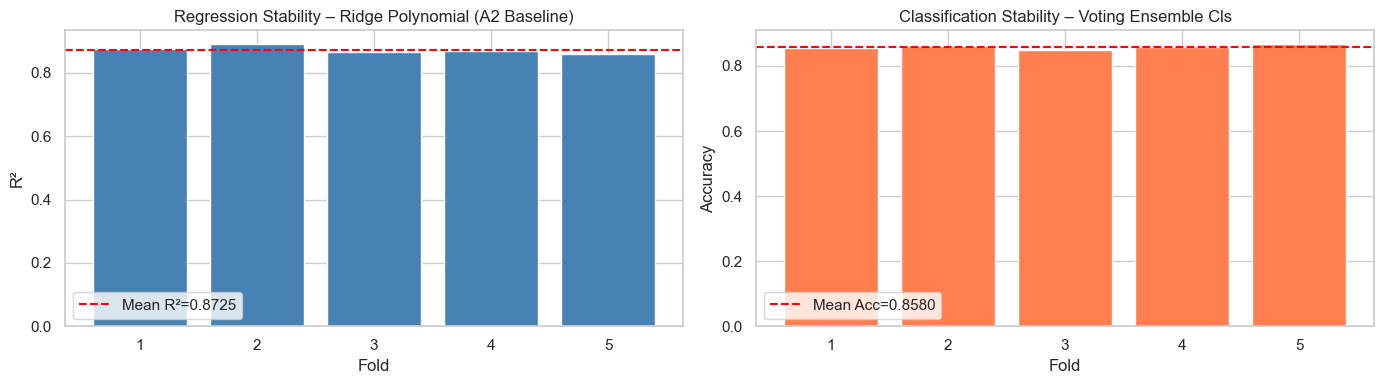

In [43]:
# ── Regression stability ──────────────────────────────────────────────────────
kf_stab = KFold(n_splits=5, shuffle=True, random_state=42)
stab_reg_r2 = []
for tr_idx, te_idx in kf_stab.split(X_reg_tr_sc):
    best_reg_model.fit(X_reg_tr_sc[tr_idx], y_reg_tr[tr_idx])
    stab_reg_r2.append(r2_score(y_reg_tr[te_idx],
                                best_reg_model.predict(X_reg_tr_sc[te_idx])))
stab_reg_r2 = np.array(stab_reg_r2)
print(f"[Regression CV]  R² per fold: {np.round(stab_reg_r2, 4)}")
print(f"  Mean: {stab_reg_r2.mean():.4f}  Std: {stab_reg_r2.std():.4f}")

# ── Classification stability ──────────────────────────────────────────────────
skf_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stab_cls_acc = []
for tr_idx, te_idx in skf_stab.split(X_cls2_tr_sc, y_cls_tr):
    best_cls_model.fit(X_cls2_tr_sc[tr_idx], y_cls_tr[tr_idx])
    stab_cls_acc.append(accuracy_score(y_cls_tr[te_idx],
                                       best_cls_model.predict(X_cls2_tr_sc[te_idx])))
stab_cls_acc = np.array(stab_cls_acc)
print(f"\n[Classification CV]  Accuracy per fold: {np.round(stab_cls_acc, 4)}")
print(f"  Mean: {stab_cls_acc.mean():.4f}  Std: {stab_cls_acc.std():.4f}")

# ── Stability bar charts ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(1,6), stab_reg_r2, color='steelblue')
axes[0].axhline(stab_reg_r2.mean(), color='red', linestyle='--',
                label=f'Mean R²={stab_reg_r2.mean():.4f}')
axes[0].set_title(f'Regression Stability – {best_reg_name}')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('R²'); axes[0].legend()

axes[1].bar(range(1,6), stab_cls_acc, color='coral')
axes[1].axhline(stab_cls_acc.mean(), color='red', linestyle='--',
                label=f'Mean Acc={stab_cls_acc.mean():.4f}')
axes[1].set_title(f'Classification Stability – {best_cls_name}')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()


## A3-7. System Comparison vs Assignment 2 Baselines

In [44]:
# ── Regression comparison table ───────────────────────────────────────────────
print("=== REGRESSION COMPARISON ===")
print(f"{'Model':<30} {'Test R²':>8}  {'Test RMSE':>10}")
print("-"*52)
for name, (model, r2_val) in reg_candidates.items():
    yp = model.predict(X_reg_te_sc)
    rmse_val = np.sqrt(mean_squared_error(y_reg_te, yp))
    tag = " ← A2 baseline" if "Baseline" in name else ""
    print(f"{name:<30} {r2_val:>8.4f}  {rmse_val:>10.4f}{tag}")

print("\n=== CLASSIFICATION COMPARISON ===")
print(f"{'Model':<35} {'Accuracy':>9}  {'F1 (weighted)':>13}")
print("-"*60)
for name, (model, acc_val) in cls_candidates.items():
    yp = model.predict(X_cls2_te_sc)
    f1_val = f1_score(y_cls_te, yp, average='weighted')
    tag = " ← A2 baseline" if "Baseline" in name else ""
    print(f"{name:<35} {acc_val:>9.4f}  {f1_val:>13.4f}{tag}")


=== REGRESSION COMPARISON ===
Model                           Test R²   Test RMSE
----------------------------------------------------
Ridge Polynomial (A2 Baseline)   0.9164      0.2208 ← A2 baseline
Random Forest Reg                0.1939      0.6877
Gradient Boosting Reg            0.1083      0.7232
SVR                              0.8943      0.2490
Voting Ensemble Reg              0.4994      0.5419

=== CLASSIFICATION COMPARISON ===
Model                                Accuracy  F1 (weighted)
------------------------------------------------------------
Logistic Regression (A2 Baseline)      0.7850         0.7880 ← A2 baseline
Random Forest Cls                      0.8348         0.8357
Gradient Boosting Cls                  0.8409         0.8417
SVC                                    0.8429         0.8442
Voting Ensemble Cls                    0.8444         0.8452
Stacking Cls                           0.8416         0.8425


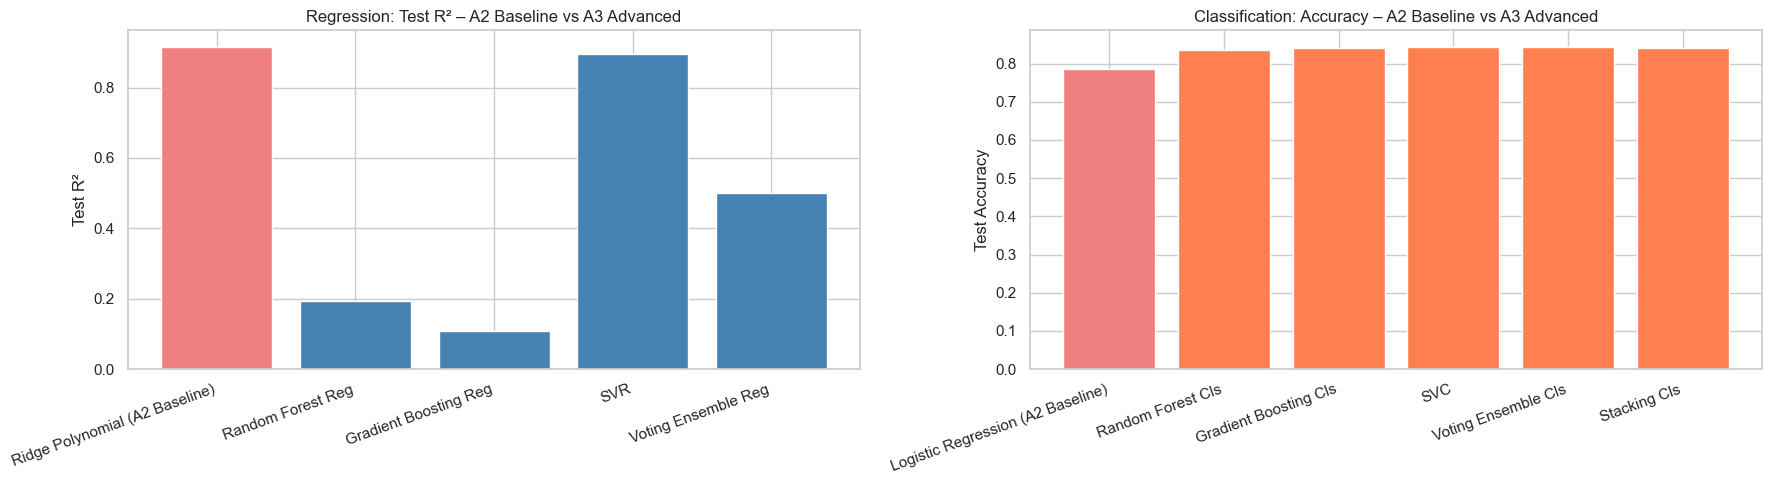

Red bars = Assignment 2 baseline. Other bars = Assignment 3 advanced models.


In [45]:
# ── Visual comparison ─────────────────────────────────────────────────────────
model_names_reg = list(reg_candidates.keys())
r2_values = [reg_candidates[n][1] for n in model_names_reg]

model_names_cls = list(cls_candidates.keys())
acc_values = [cls_candidates[n][1] for n in model_names_cls]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

colors_reg = ['lightcoral' if 'Baseline' in n else 'steelblue' for n in model_names_reg]
axes[0].bar(model_names_reg, r2_values, color=colors_reg)
axes[0].set_title('Regression: Test R² – A2 Baseline vs A3 Advanced')
axes[0].set_ylabel('Test R²')
axes[0].set_xticklabels(model_names_reg, rotation=20, ha='right')

colors_cls = ['lightcoral' if 'Baseline' in n else 'coral' for n in model_names_cls]
axes[1].bar(model_names_cls, acc_values, color=colors_cls)
axes[1].set_title('Classification: Accuracy – A2 Baseline vs A3 Advanced')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_xticklabels(model_names_cls, rotation=20, ha='right')

plt.tight_layout(); plt.show()
print("Red bars = Assignment 2 baseline. Other bars = Assignment 3 advanced models.")


## A3-8. Bias–Variance Diagnosis via Learning Curves

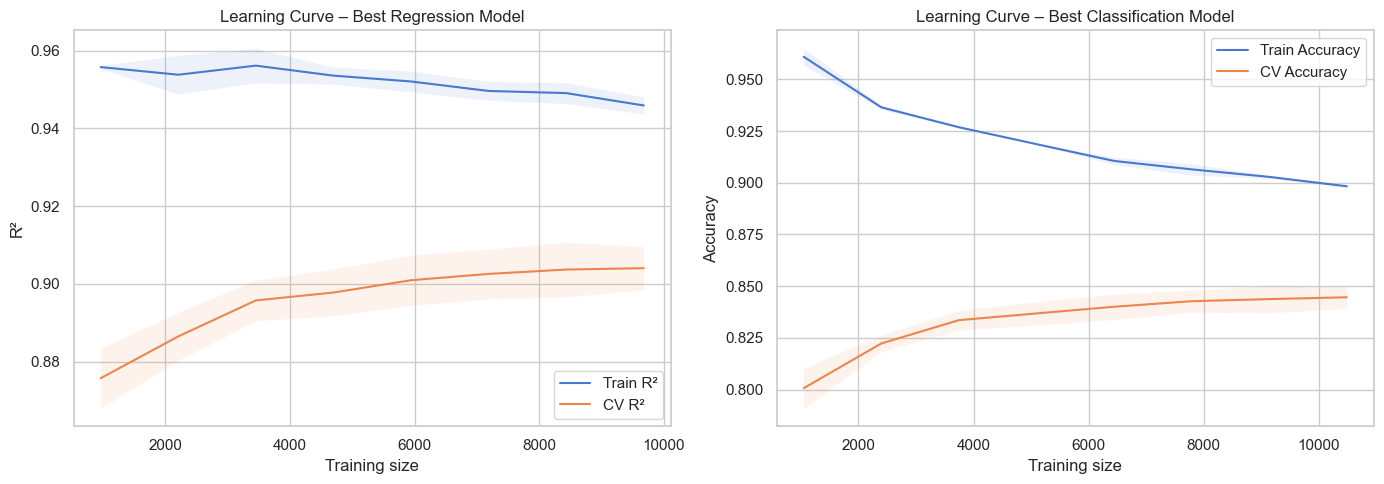


Bias-Variance Interpretation:
  - Large gap (Train >> CV): HIGH VARIANCE (overfitting)
    → Fix: more data, stronger regularization, simpler model.
  - Both low and converging: HIGH BIAS (underfitting)
    → Fix: more complex model, add features, reduce regularization.
  - Converging high scores: well-generalized model ✓



In [46]:
# ── Learning curves for best regression and classification models ──────────────
train_sizes = np.linspace(0.1, 1.0, 8)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression learning curve
tr_sz, tr_sc_lc, te_sc_lc = learning_curve(
    best_rf_reg, X_reg_tr_sc, y_reg_tr,
    train_sizes=train_sizes, cv=3, scoring='r2', n_jobs=-1)
axes[0].plot(tr_sz, tr_sc_lc.mean(axis=1), label='Train R²')
axes[0].plot(tr_sz, te_sc_lc.mean(axis=1), label='CV R²')
axes[0].fill_between(tr_sz, tr_sc_lc.mean(1)-tr_sc_lc.std(1),
                      tr_sc_lc.mean(1)+tr_sc_lc.std(1), alpha=0.1)
axes[0].fill_between(tr_sz, te_sc_lc.mean(1)-te_sc_lc.std(1),
                      te_sc_lc.mean(1)+te_sc_lc.std(1), alpha=0.1)
axes[0].set_title('Learning Curve – Best Regression Model')
axes[0].set_xlabel('Training size'); axes[0].set_ylabel('R²'); axes[0].legend()

# Classification learning curve
tr_sz2, tr_sc2_lc, te_sc2_lc = learning_curve(
    best_rf_cls, X_cls2_tr_sc, y_cls_tr,
    train_sizes=train_sizes, cv=3, scoring='accuracy', n_jobs=-1)
axes[1].plot(tr_sz2, tr_sc2_lc.mean(axis=1), label='Train Accuracy')
axes[1].plot(tr_sz2, te_sc2_lc.mean(axis=1), label='CV Accuracy')
axes[1].fill_between(tr_sz2, tr_sc2_lc.mean(1)-tr_sc2_lc.std(1),
                      tr_sc2_lc.mean(1)+tr_sc2_lc.std(1), alpha=0.1)
axes[1].fill_between(tr_sz2, te_sc2_lc.mean(1)-te_sc2_lc.std(1),
                      te_sc2_lc.mean(1)+te_sc2_lc.std(1), alpha=0.1)
axes[1].set_title('Learning Curve – Best Classification Model')
axes[1].set_xlabel('Training size'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout(); plt.show()

print("""
Bias-Variance Interpretation:
  - Large gap (Train >> CV): HIGH VARIANCE (overfitting)
    → Fix: more data, stronger regularization, simpler model.
  - Both low and converging: HIGH BIAS (underfitting)
    → Fix: more complex model, add features, reduce regularization.
  - Converging high scores: well-generalized model ✓
""")


## A3-9. Export results.json

In [47]:
results = {
    "group_members": [
     {"name": "Mohamed Ashraf Khairallah ", "id": "2401248500"},
        {"name": "Ahmed Ramadan Mohamed", "id": "2401245405"},
        {"name": "David Emil Fekry Nasrallah Beshay ", "id": "2401243218"},
        {"name": "Mohamed Farghaly Ali Farghaly", "id": "2401241621"}    ],
    
    "best_hyperparameters": {
        "Ridge_regression_alpha":           float(best_ridge_alpha),
        "Lasso_regression_alpha":           float(best_lasso_alpha),
        "LogisticRegression_C":             float(best_C_l2),
        "RandomForest_Regression":          rf_reg_gs.best_params_,
        "RandomForest_Classification":      rf_cls_gs.best_params_,
        "GradientBoosting_Regression":      gb_reg_gs.best_params_,
        "GradientBoosting_Classification":  gb_cls_gs.best_params_,
        "SVR":                              svr_gs.best_params_,
        "SVC":                              svc_gs.best_params_
    },
    "cv_stability": {
        "regression": {
            "model":  best_reg_name,
            "metric": "R2",
            "mean":   float(round(stab_reg_r2.mean(), 4)),
            "std":    float(round(stab_reg_r2.std(),  4)),
            "folds":  [float(round(v, 4)) for v in stab_reg_r2]
        },
        "classification": {
            "model":  best_cls_name,
            "metric": "Accuracy",
            "mean":   float(round(stab_cls_acc.mean(), 4)),
            "std":    float(round(stab_cls_acc.std(),  4)),
            "folds":  [float(round(v, 4)) for v in stab_cls_acc]
        }
    }
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("results.json saved successfully.")
print(json.dumps(results, indent=2))


results.json saved successfully.
{
  "group_members": [
    {
      "name": "Mohamed Ashraf Khairallah ",
      "id": "2401248500"
    },
    {
      "name": "Ahmed Ramadan Mohamed",
      "id": "2401245405"
    },
    {
      "name": "David Emil Fekry Nasrallah Beshay ",
      "id": "2401243218"
    },
    {
      "name": "Mohamed Farghaly Ali Farghaly",
      "id": "2401241621"
    }
  ],
  "best_hyperparameters": {
    "Ridge_regression_alpha": 0.001,
    "Lasso_regression_alpha": 0.001,
    "LogisticRegression_C": 0.1623776739188721,
    "RandomForest_Regression": {
      "max_depth": 10,
      "min_samples_leaf": 2,
      "n_estimators": 200
    },
    "RandomForest_Classification": {
      "max_depth": 10,
      "n_estimators": 200
    },
    "GradientBoosting_Regression": {
      "learning_rate": 0.05,
      "max_depth": 5,
      "n_estimators": 100
    },
    "GradientBoosting_Classification": {
      "learning_rate": 0.05,
      "max_depth": 5,
      "n_estimators": 200
    },